# Telco Customer Churn

**Telco Customer Churn Dataset Overview**
- The dataset contains ~7,044 customers of a telecom company.
- Each row represents one customer, and columns describe demographics, services used, billing, and contract details.
- The target variable is Churn (Yes/No) – whether the customer left the company.
- Features include:
  * Demographics: gender, senior citizen, partner, dependents
  * Account info: tenure, contract type, paperless billing
  * Services: phone, internet, online security, streaming TV/movies
  * Billing: monthly charges, total charges, payment method
- The dataset is realistic and anonymized, provided by IBM, and commonly used for customer churn prediction projects.
- Useful for exploratory data analysis, feature engineering, and classification model building.

## **Problem Statment**
**"Given customer details, services, and billing information, predict whether a customer will leave the telecom company."**

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/Telco_Customer_Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
df.shape

(7043, 21)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [36]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Data Checks to perform**

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [37]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [38]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [39]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


***Changing the dtype for Total Charges Colunm from object to int***

In [40]:
print(df['TotalCharges'].dtype)

object


In [41]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [42]:
print(df['TotalCharges'].dtype)

float64


## **Exploring Data**
**Categorical data**

In [43]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [44]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'Partner variable:     ",end=" " )
print(df['Partner'].unique())

print("Categories in 'Dependents' variable:     ",end=" " )
print(df['Dependents'].unique())

print("Categories in 'PhoneService' variable:     ",end=" " )
print(df['PhoneService'].unique())

print("Categories in 'MultipleLines' variable:     ",end=" " )
print(df['MultipleLines'].unique())

print("Categories in 'InternetService' variable:     ",end=" " )
print(df['InternetService'].unique())

print("Categories in 'OnlineSecurity' variable:     ",end=" " )
print(df['OnlineSecurity'].unique())

print("Categories in 'OnlineBackup' variable:     ",end=" " )
print(df['OnlineBackup'].unique())

print("Categories in 'DeviceProtection' variable:     ",end=" " )
print(df['DeviceProtection'].unique())

print("Categories in 'TechSupport' variable:     ",end=" " )
print(df['TechSupport'].unique())

print("Categories in 'StreamingTV' variable:     ",end=" " )
print(df['StreamingTV'].unique())

print("Categories in 'StreamingMovies' variable:     ",end=" " )
print(df['StreamingMovies'].unique())

print("Categories in 'Contract' variable:     ",end=" " )
print(df['Contract'].unique())

print("Categories in 'PaperlessBilling' variable:     ",end=" " )
print(df['PaperlessBilling'].unique())

print("Categories in 'PaymentMethod' variable:",end=" " )
print(df['PaymentMethod'].unique())

print("Categories in 'Churn' variable:     ",end=" " )
print(df['Churn'].unique())


Categories in 'gender' variable:      ['Female' 'Male']
Categories in 'Partner variable:      ['Yes' 'No']
Categories in 'Dependents' variable:      ['No' 'Yes']
Categories in 'PhoneService' variable:      ['No' 'Yes']
Categories in 'MultipleLines' variable:      ['No phone service' 'No' 'Yes']
Categories in 'InternetService' variable:      ['DSL' 'Fiber optic' 'No']
Categories in 'OnlineSecurity' variable:      ['No' 'Yes' 'No internet service']
Categories in 'OnlineBackup' variable:      ['Yes' 'No' 'No internet service']
Categories in 'DeviceProtection' variable:      ['No' 'Yes' 'No internet service']
Categories in 'TechSupport' variable:      ['No' 'Yes' 'No internet service']
Categories in 'StreamingTV' variable:      ['No' 'Yes' 'No internet service']
Categories in 'StreamingMovies' variable:      ['No' 'Yes' 'No internet service']
Categories in 'Contract' variable:      ['Month-to-month' 'One year' 'Two year']
Categories in 'PaperlessBilling' variable:      ['Yes' 'No']
Categor

Defining numerical feature and Categorical feature

In [45]:
numerical_features=[features for features in df.columns if df[features].dtype !='O']
categorical_features=[features for features in df.columns if df[features].dtype =='O']

print(f"* {len(numerical_features)} Numerical features:",numerical_features)
print(f"* {len(categorical_features)} Categorical features:",categorical_features)

* 4 Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
* 17 Categorical features: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


## Visualizations


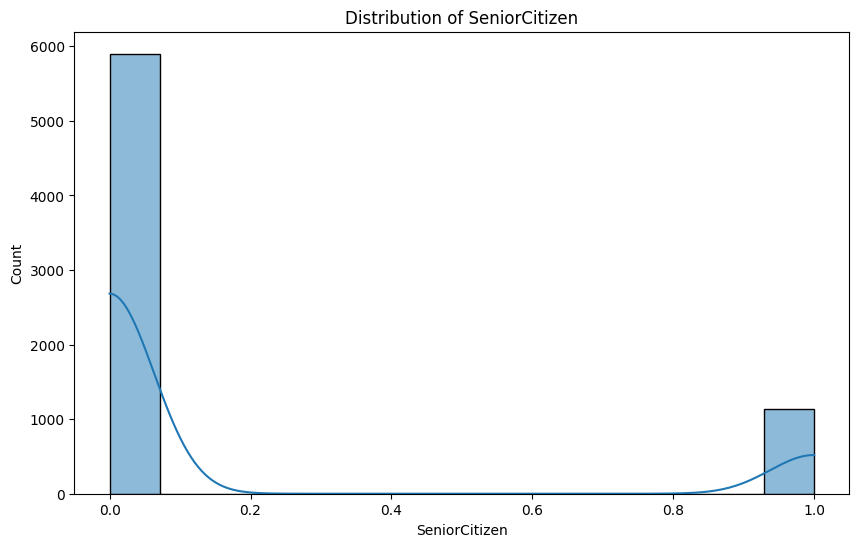

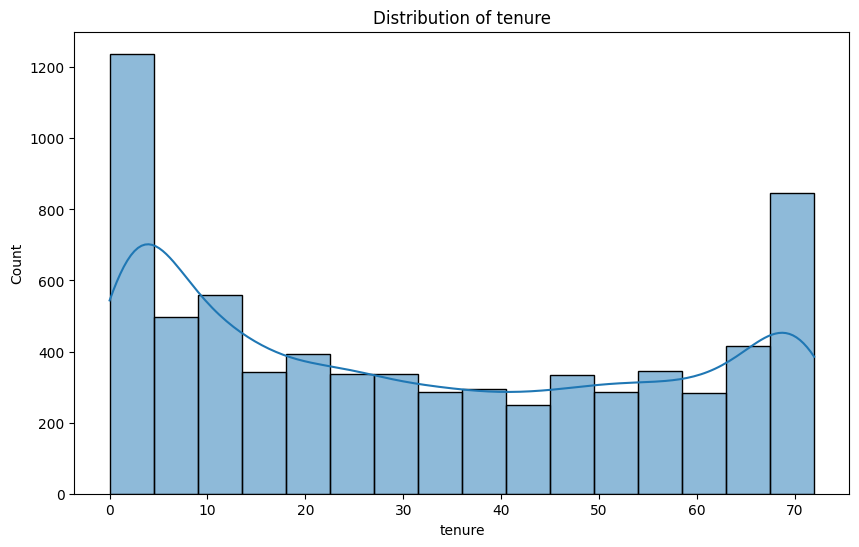

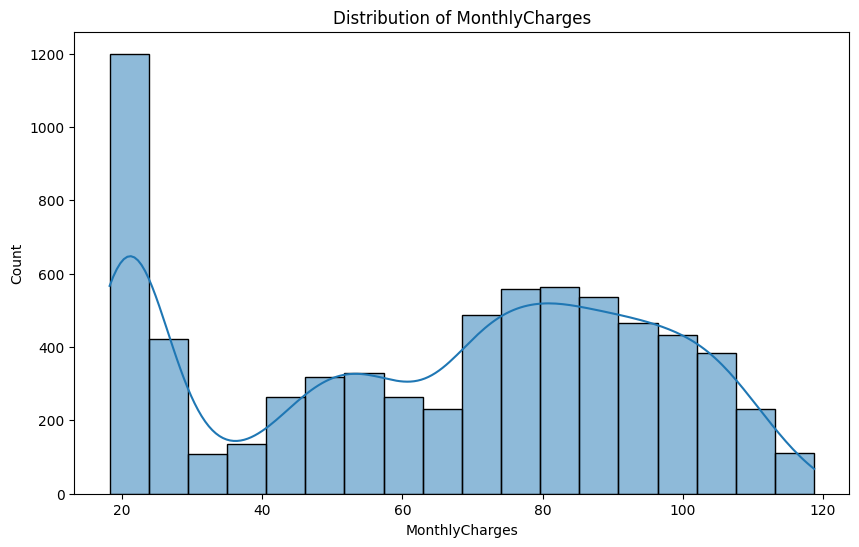

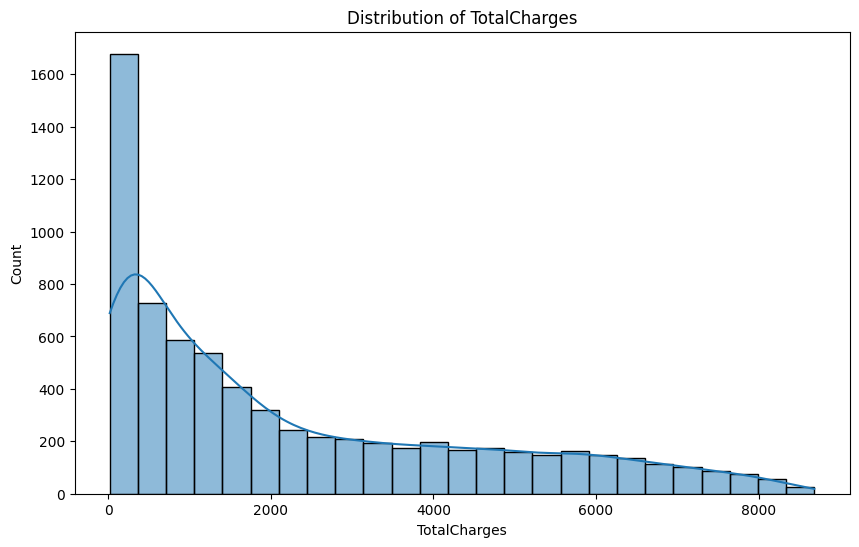

In [46]:
#Numerical data
num_col=['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_col:
  plt.figure(figsize=(10,6))
  sns.histplot(x=df[col],kde=True)
  plt.title(f"Distribution of {col}")
  plt.show

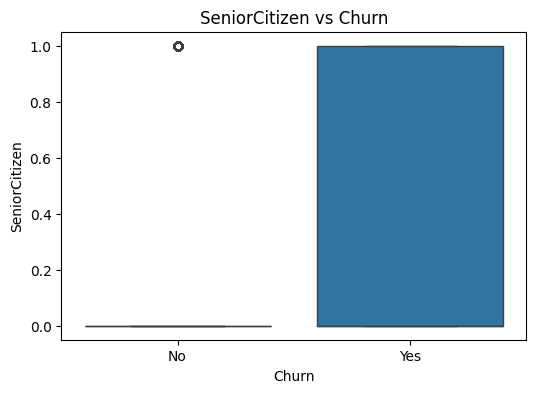

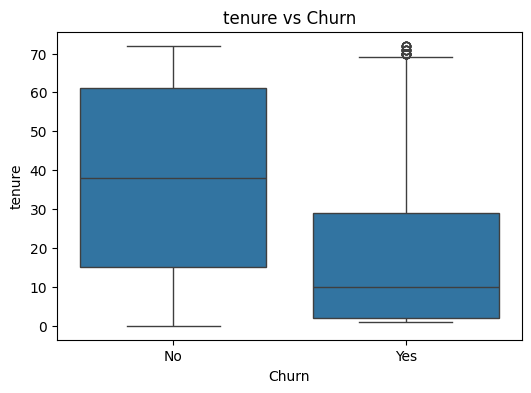

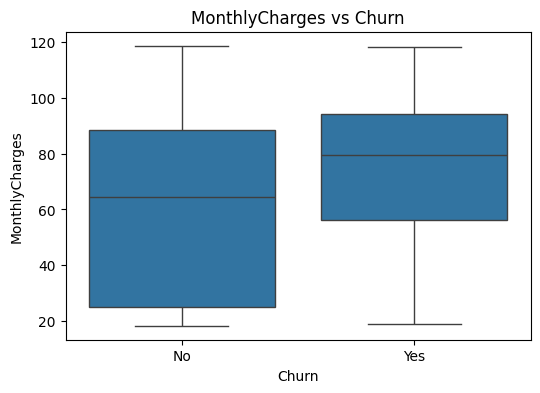

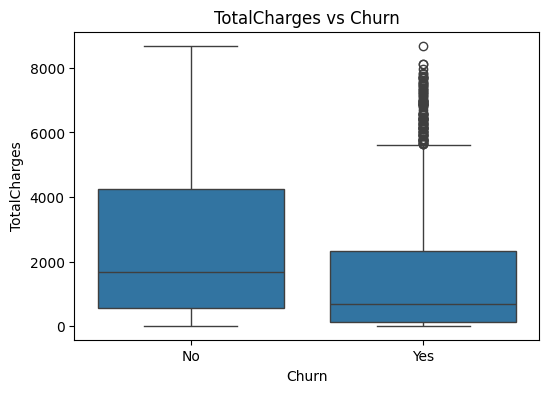

In [47]:
#BOXPLOT

for col in num_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.show()


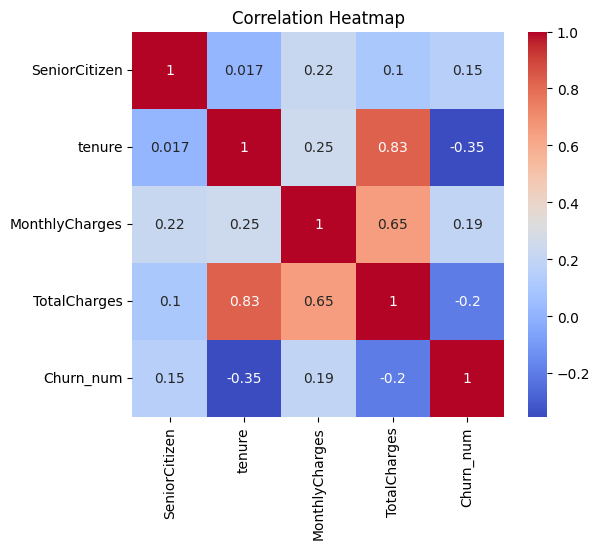

In [48]:
df['Churn_num'] = df['Churn'].map({'No':0, 'Yes':1})
plt.figure(figsize=(6,5))
sns.heatmap(df[num_col + ['Churn_num']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


**Categorical Data visualization**

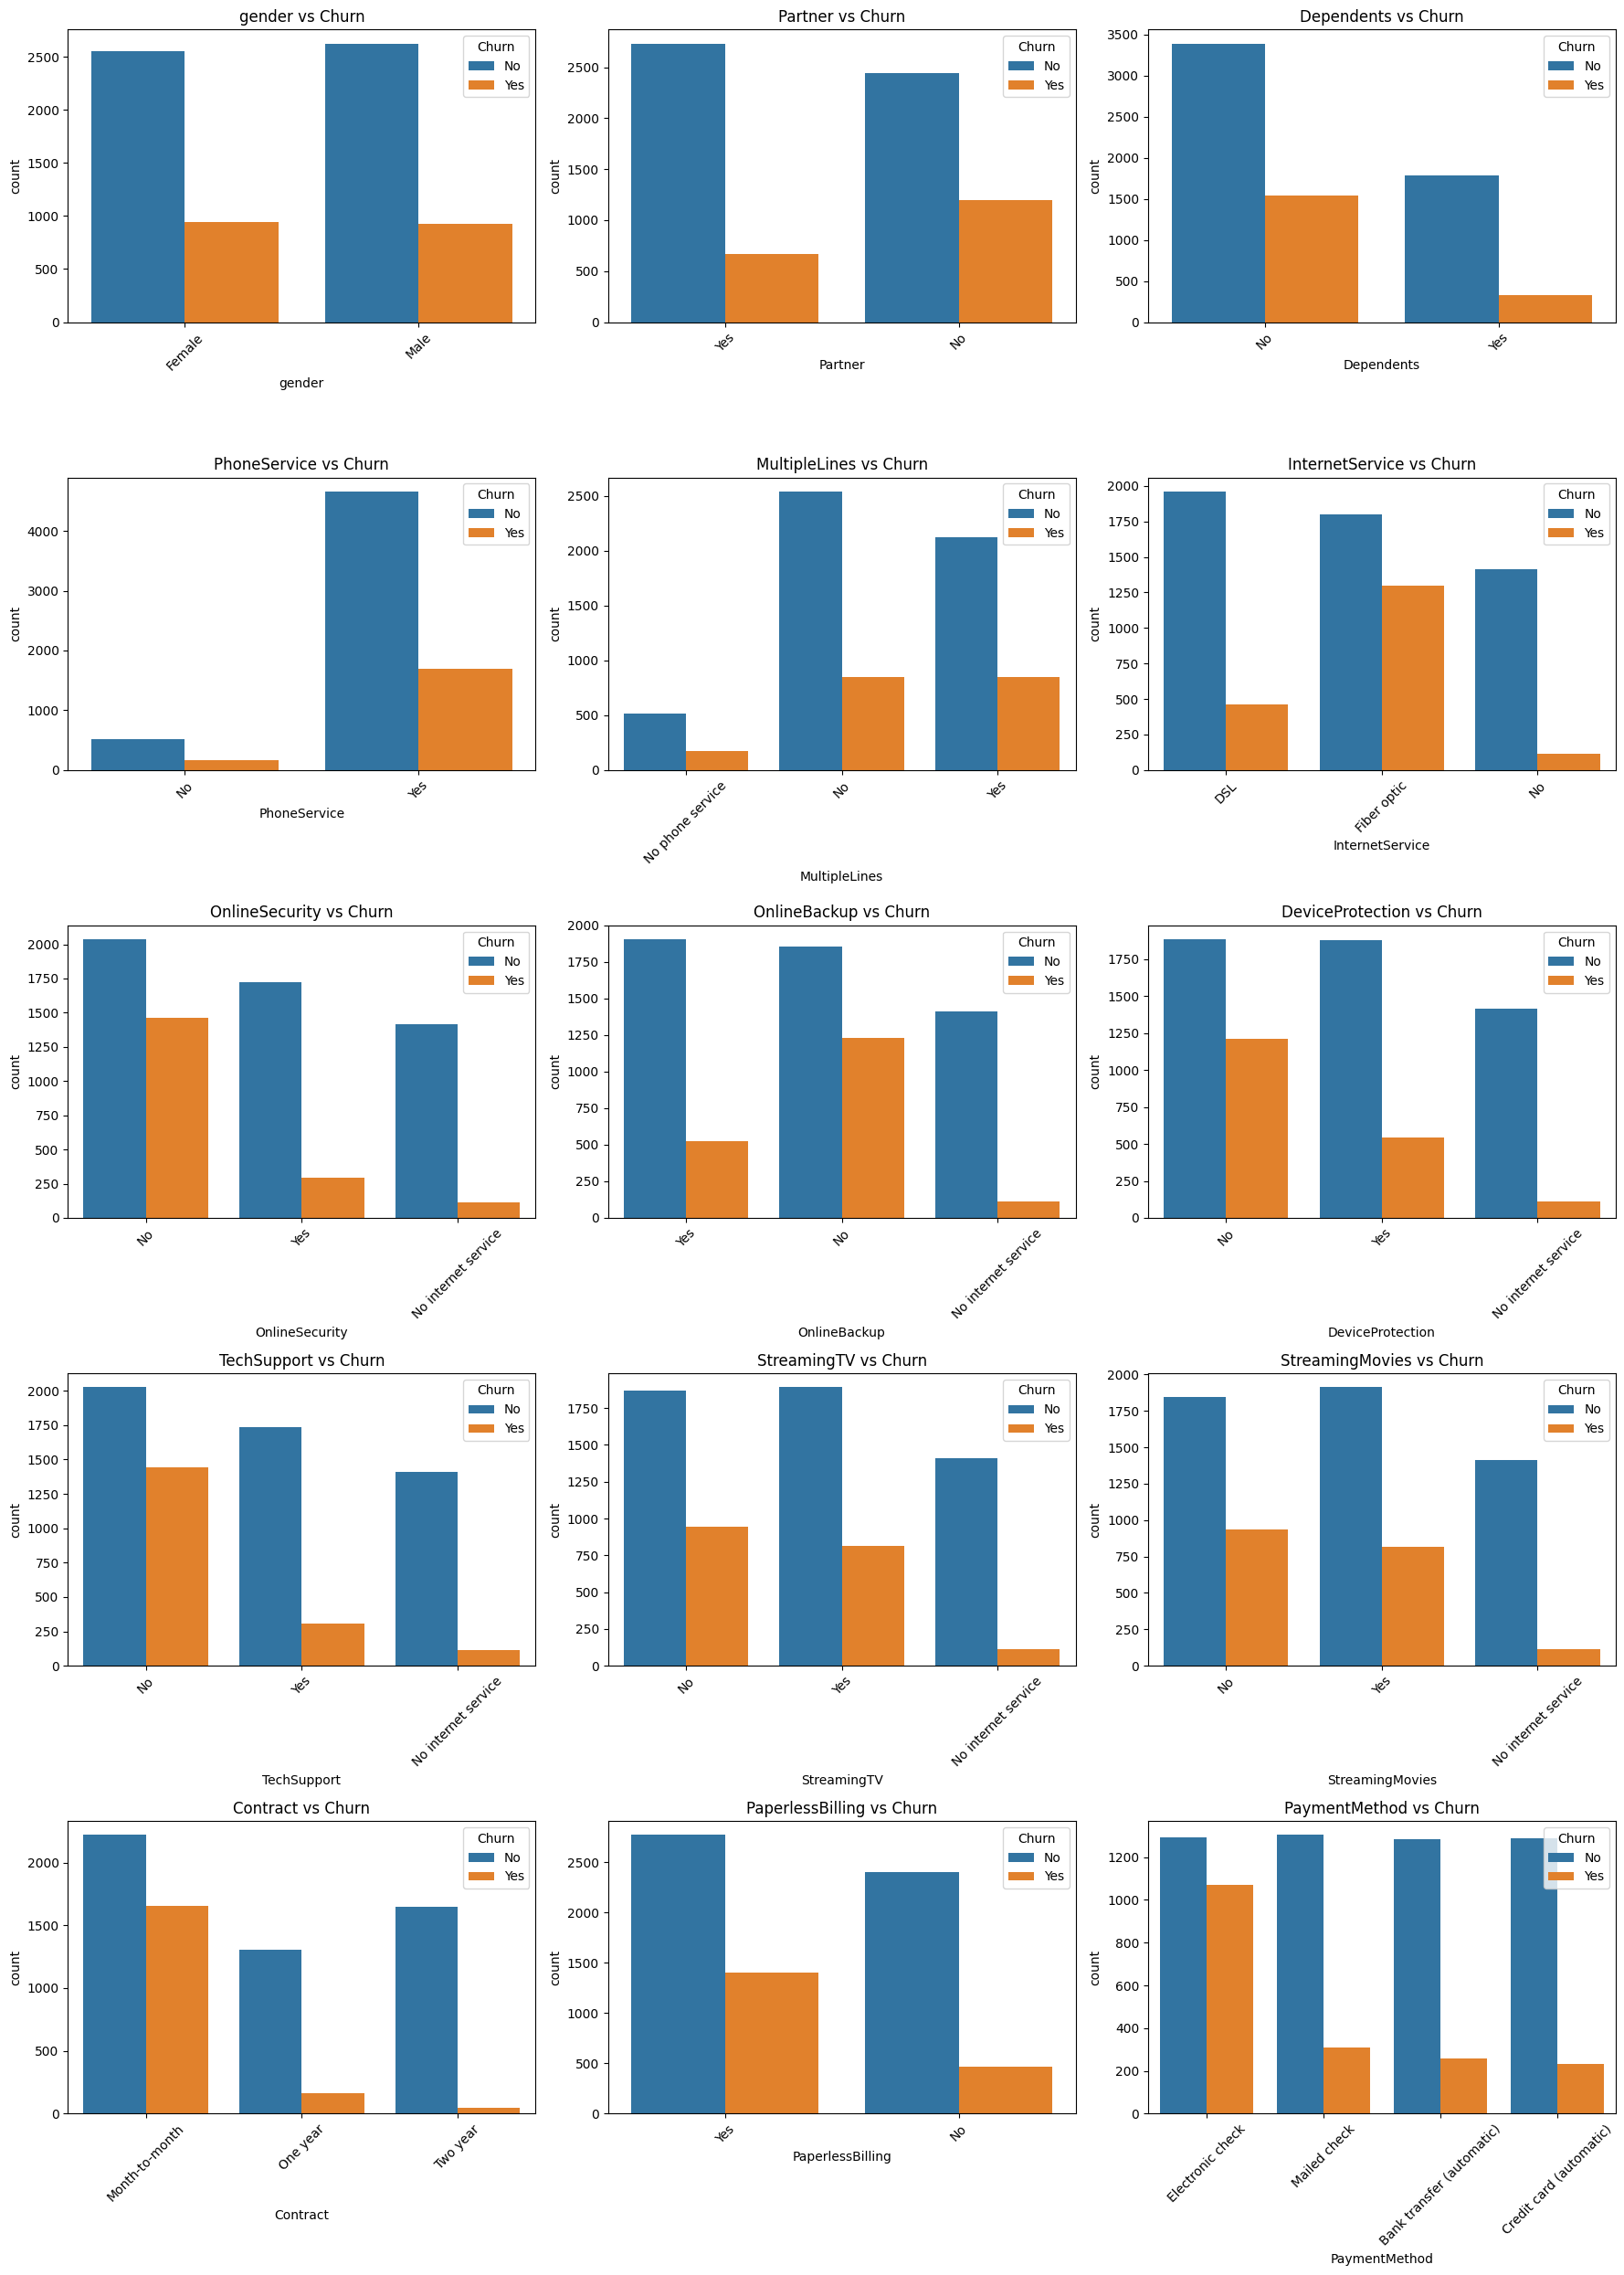

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

plots_per_row = 3
num_rows = math.ceil(len(cat_cols) / plots_per_row)

plt.figure(figsize=(18, 5*num_rows))  # Adjust height according to rows

for i, col in enumerate(cat_cols):
    plt.subplot(num_rows, plots_per_row, i+1)
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


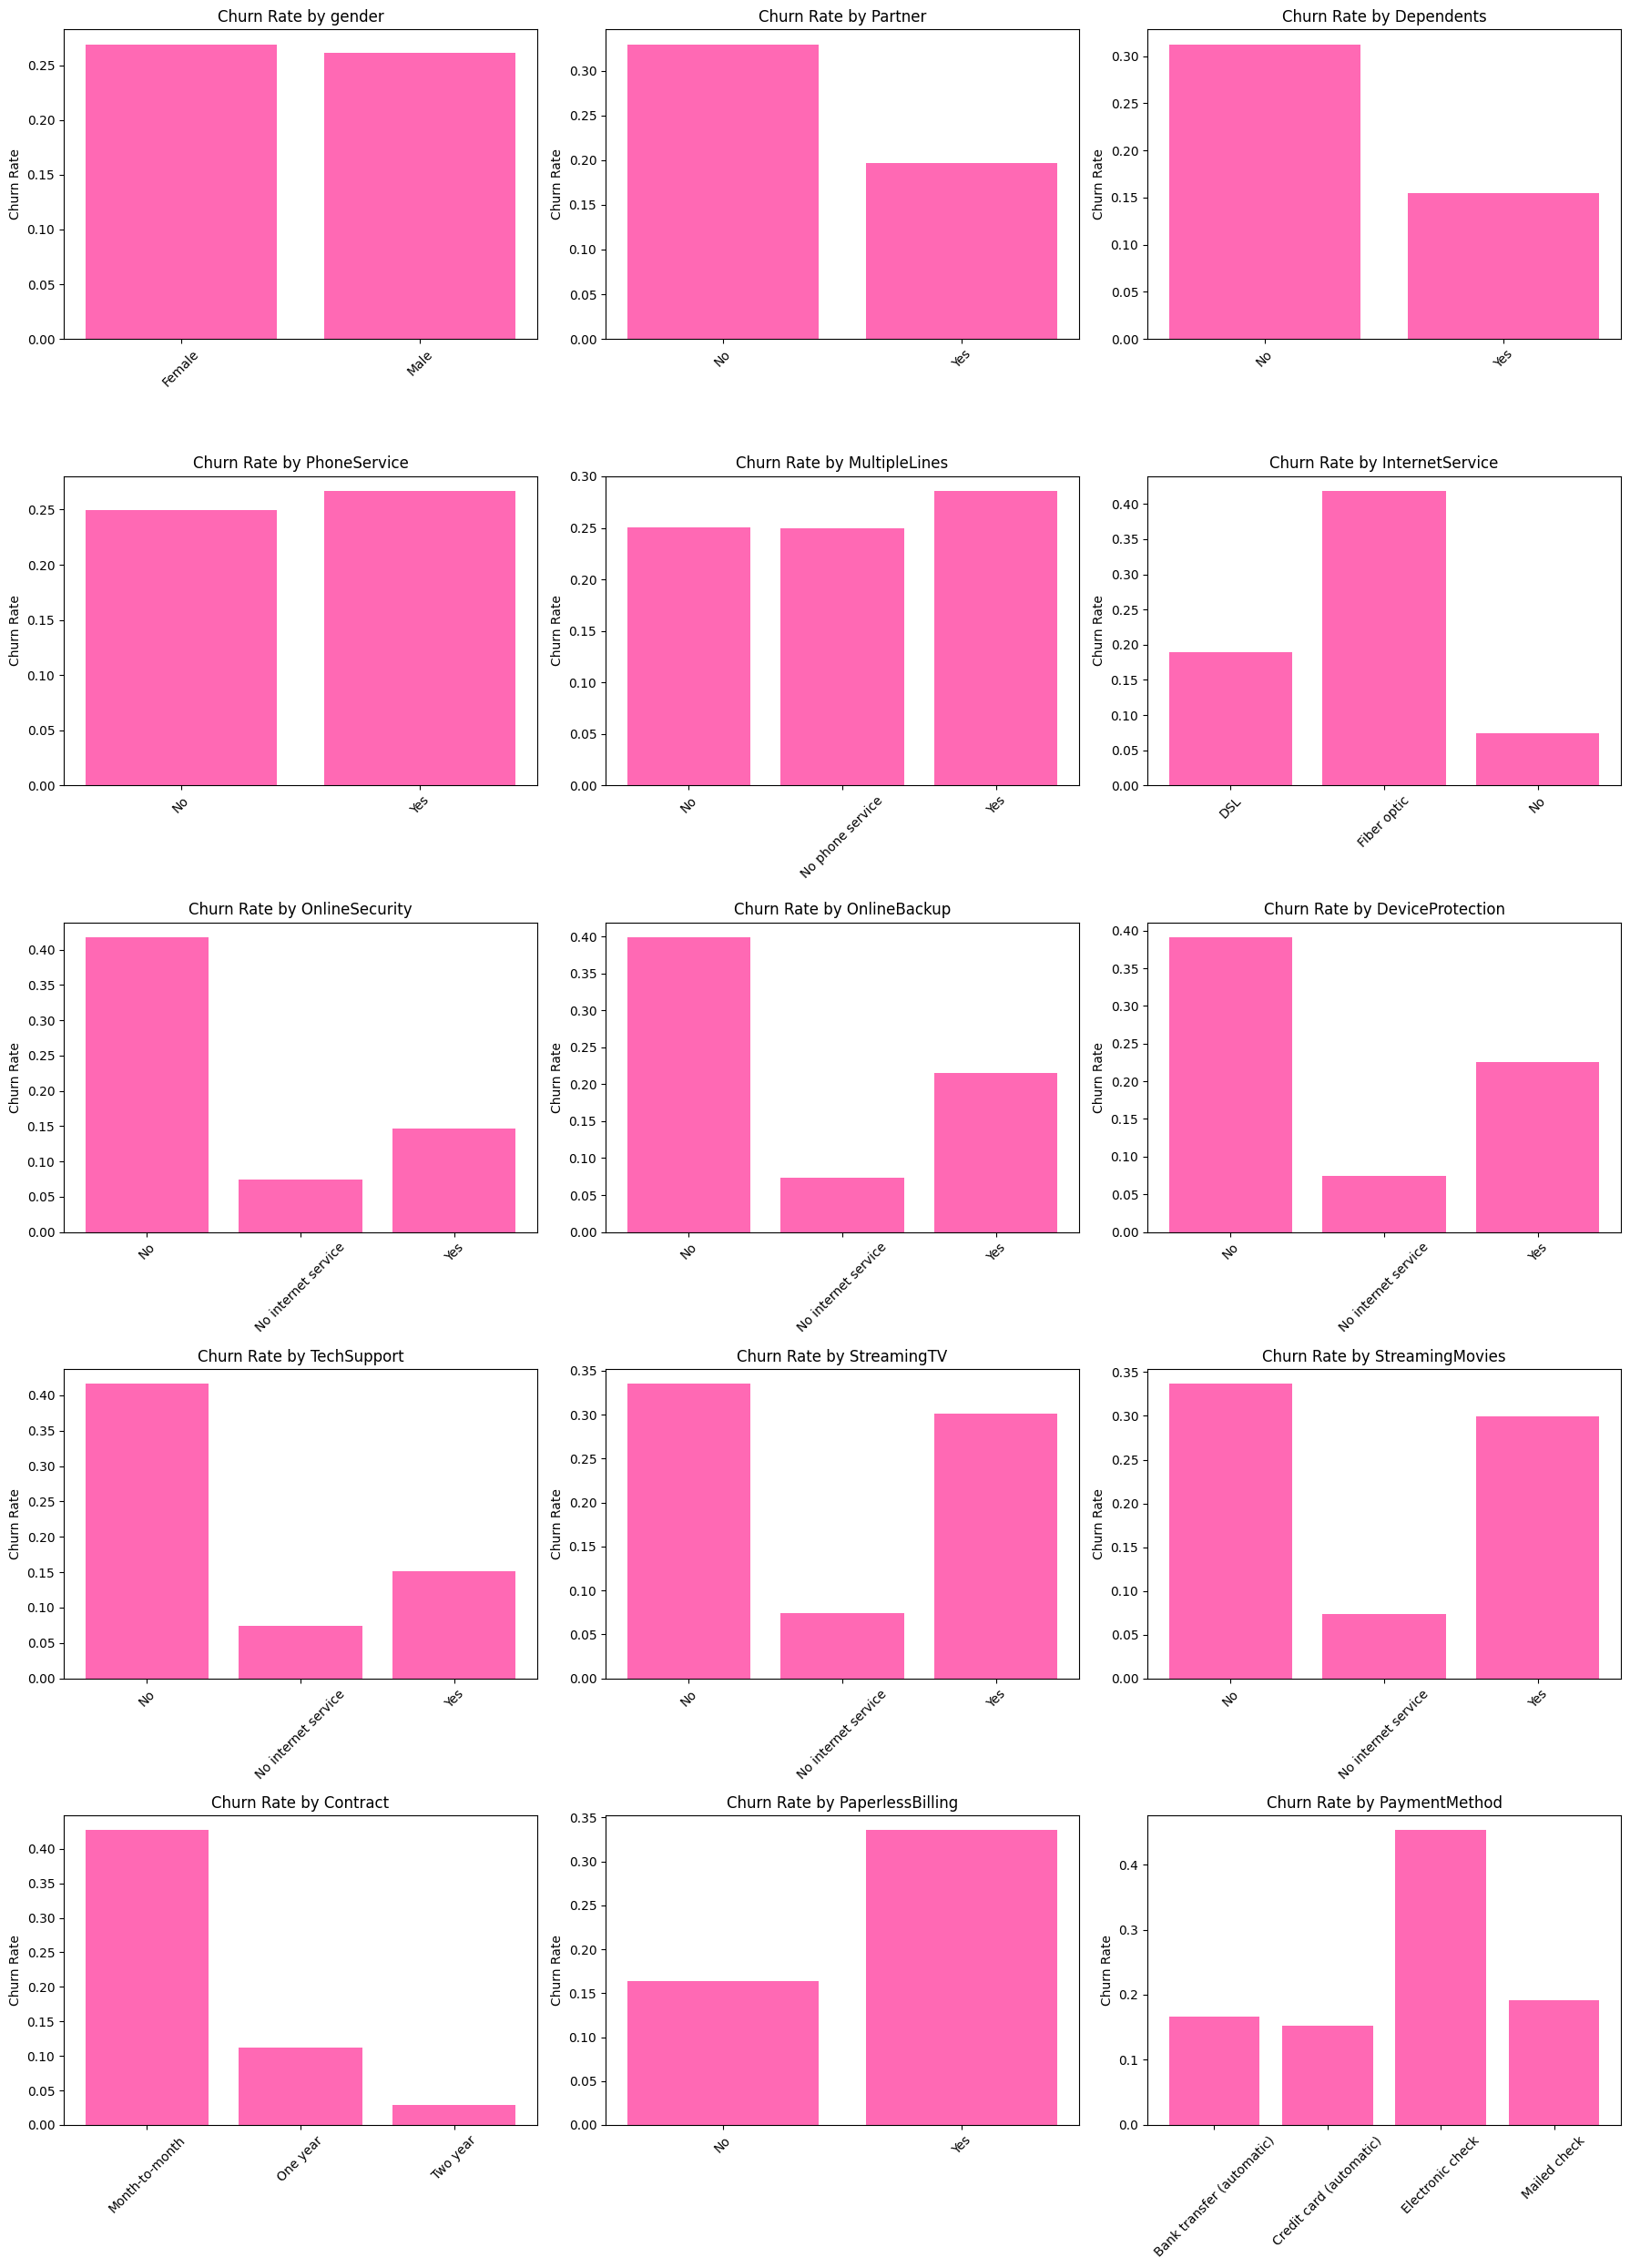

In [59]:
import matplotlib.pyplot as plt
import math

plots_per_row = 3
num_rows = math.ceil(len(cat_cols) / plots_per_row)

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(18, 5*num_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_pct = df.groupby(col)['Churn_num'].mean()
    axes[i].bar(churn_pct.index, churn_pct.values, color='hotpink')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


PairPlot on numerical feature with churn

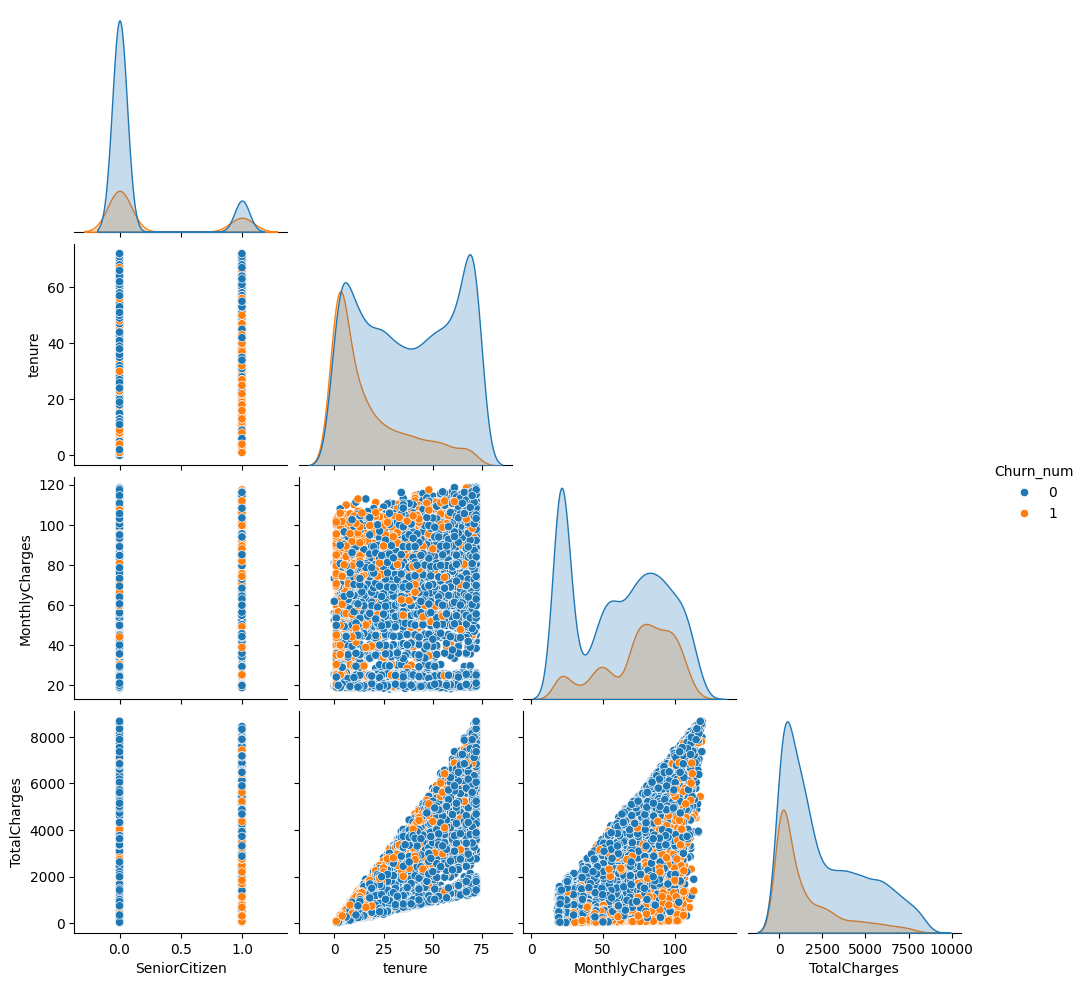

In [60]:
sns.pairplot(df[num_col + ['Churn_num']], hue='Churn_num', corner=True)
plt.show()